# Assignment 1: Housing Price Prediction

**Goal:** Predict `SalePrice` for houses in the Ames Housing dataset using a complete machine-learning workflow:

**Explore data → Split data → Preprocess → Select/engineer features → Train models → Evaluate and interpret**

The focus is not the highest possible score, but understanding the data and being able to **explain and justify** your decisions. Write short explanations in the markdown cells along the way (replace the text marked *✏️ Your answer*).

> Use only `data/AmesHousing.csv`, and the *Ames Housing – Understanding the Dataset* guide whenever a column name or code is unclear.

## 0. Setup

Import the libraries you need. This cell is already filled in – add more imports if needed.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42          # used everywhere for reproducible results
pd.set_option("display.max_columns", 100)

### Load the dataset

In [66]:
df = pd.read_csv("AmesHousing.csv")
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
## Step 1 – Explore and understand the data

Explore the dataset using descriptive statistics and visualizations. Choose analyses that actually help you make later decisions – do not create plots just for the sake of it.

The assignment asks you to investigate:
1. the available variables and their data types
2. the distribution of `SalePrice`
3. missing values
4. unusual values or patterns
5. relationships that may be useful for predicting house prices

### 1.1 Variables and data types

In [67]:
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

In [68]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols)
cat_cols = df.select_dtypes(exclude="number").columns
print(cat_cols)

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'B

*✏️ Your answer: What kinds of variables do we have? Are there columns with the wrong type or that are not useful?*

### 1.2 Distribution of `SalePrice`

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.7435000757376466


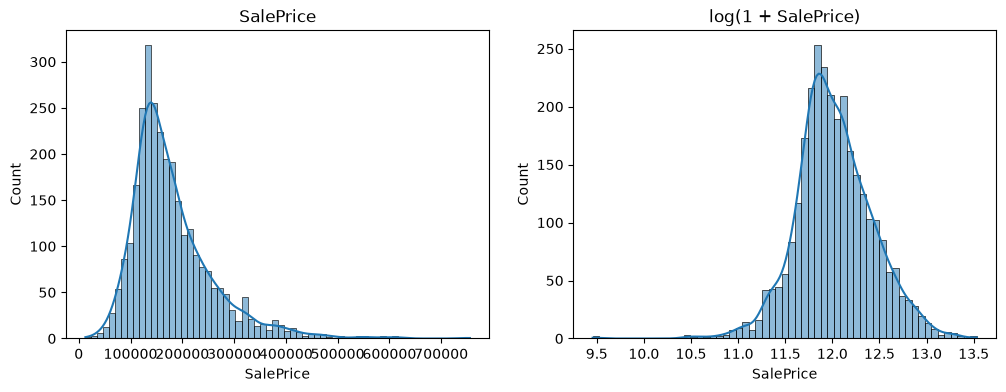

In [69]:
print(df["SalePrice"].describe())
print("Skewness:", df["SalePrice"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log(1 + SalePrice)")
plt.show()

*✏️ Your answer: What does the distribution look like? Is it skewed? Could a log transformation be useful?*

### 1.3 Missing values

In [70]:
missing_count = df.isnull().sum()                 # antall NaN per kolonne
missing_pct = missing_count / len(df) * 100       # andel i prosent

missing = pd.DataFrame({
    "Missing": missing_count,
    "Percent": missing_pct.round(2)
})

missing = missing[missing["Missing"] > 0].sort_values("Missing", ascending=False)
print(f"{len(missing)} columns have missing values")
missing

27 columns have missing values


,Missing,Percent
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


*✏️ Your answer: Which columns have many missing values? Does "missing" actually mean "does not exist"?*
*(E.g. `Pool QC` = NA usually means "no pool" according to the guide – that is information, not an error.)*

### 1.4 Unusual values and patterns

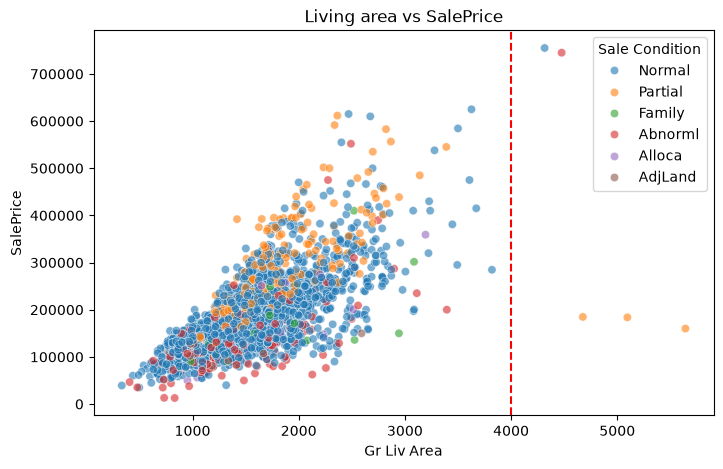

,Gr Liv Area,SalePrice,Sale Condition,Neighborhood,Overall Qual
1498,5642,160000,Partial,Edwards,10
1760,4476,745000,Abnorml,NoRidge,10
1767,4316,755000,Normal,NoRidge,10
2180,5095,183850,Partial,Edwards,10
2181,4676,184750,Partial,Edwards,10


In [71]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Gr Liv Area", y="SalePrice", hue="Sale Condition", data=df, alpha=0.6)
plt.axvline(4000, color="red", linestyle="--")
plt.title("Living area vs SalePrice")
plt.show()

df[df["Gr Liv Area"] > 4000][["Gr Liv Area", "SalePrice", "Sale Condition", "Neighborhood", "Overall Qual"]]

In [72]:
df.describe().T[["min", "max"]]
print(df[df["Garage Yr Blt"] > df["Yr Sold"]][["Year Built", "Garage Yr Blt", "Yr Sold"]])
print(df[df["Year Remod/Add"] < df["Year Built"]][["Year Built", "Year Remod/Add"]])
print(df[df["Yr Sold"] < df["Year Built"]][["Year Built", "Yr Sold"]])

      Year Built  Garage Yr Blt  Yr Sold
2180        2008         2008.0     2007
2260        2006         2207.0     2007
     Year Built  Year Remod/Add
850        2002            2001
      Year Built  Yr Sold
2180        2008     2007


In [73]:
# Share of the most frequent value in each categorical column
top_share = df[cat_cols].apply(lambda c: c.value_counts(normalize=True, dropna=False).iloc[0])
top_share.sort_values(ascending=False).head(10)

Utilities       0.998976
Street          0.995904
Pool QC         0.995563
Condition 2     0.989761
Roof Matl       0.985324
Heating         0.984642
Misc Feature    0.963823
Land Slope      0.951877
Central Air     0.933106
Alley           0.932423
dtype: float64

*✏️ Your answer: Which unusual observations did you find, and what will you do with them?*

### 1.5 Relationships with `SalePrice`

In [74]:
corr = df.drop(columns=["Order", "PID"]).corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0

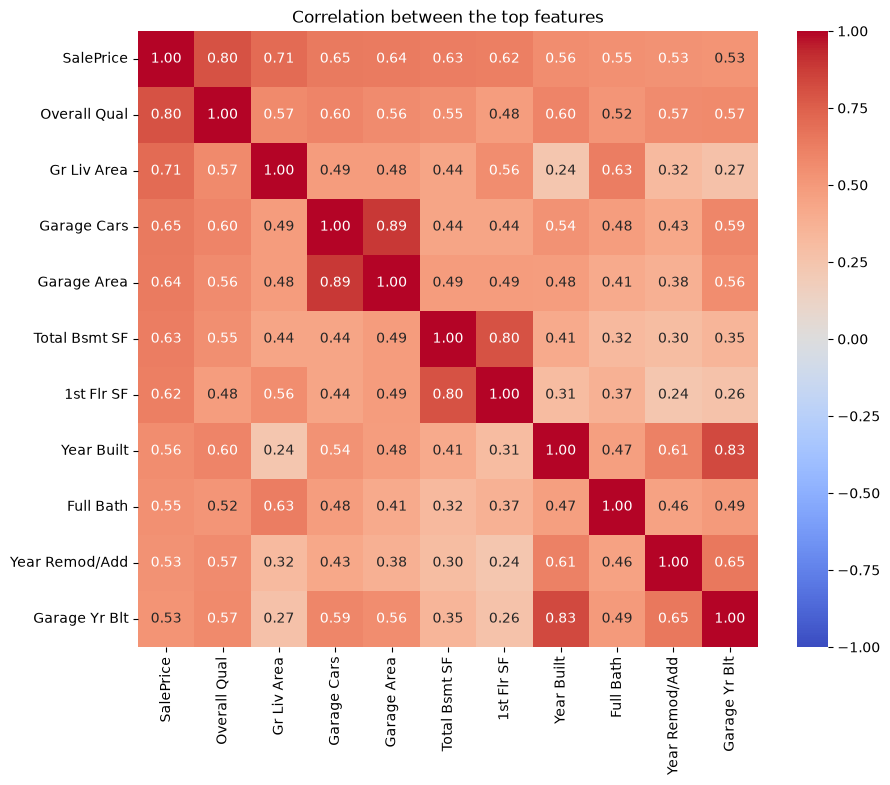

In [75]:
top10 = corr["SalePrice"].abs().sort_values(ascending=False).index[:11]   # SalePrice + top 10

plt.figure(figsize=(10, 8))
sns.heatmap(corr.loc[top10, top10], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between the top features")
plt.show()

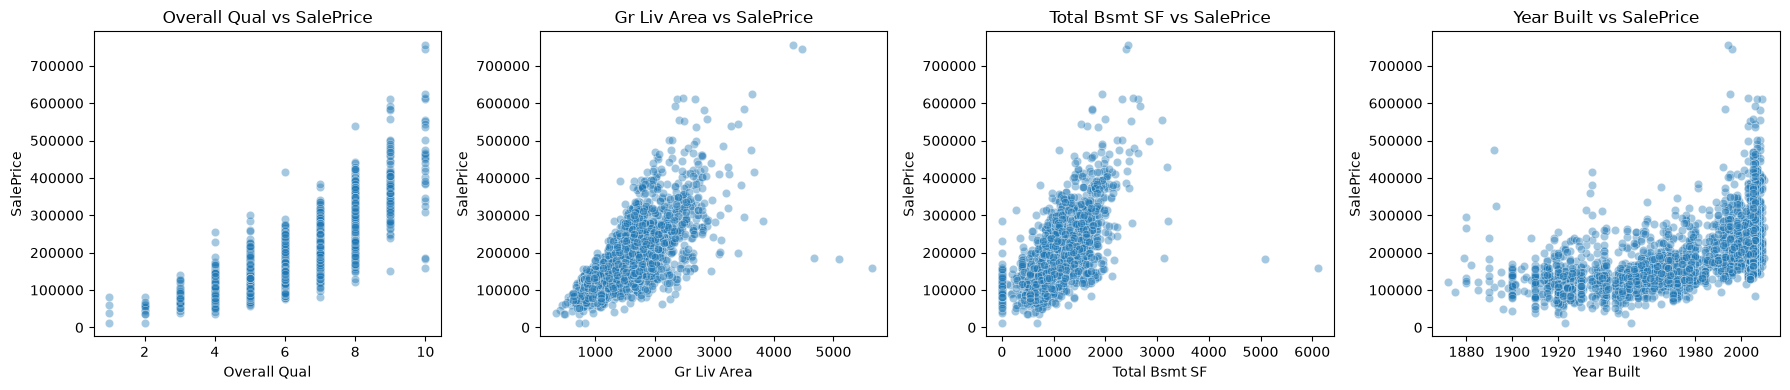

In [76]:
features = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Year Built"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, features):
    sns.scatterplot(x=col, y="SalePrice", data=df, alpha=0.4, ax=ax)
    ax.set_title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()

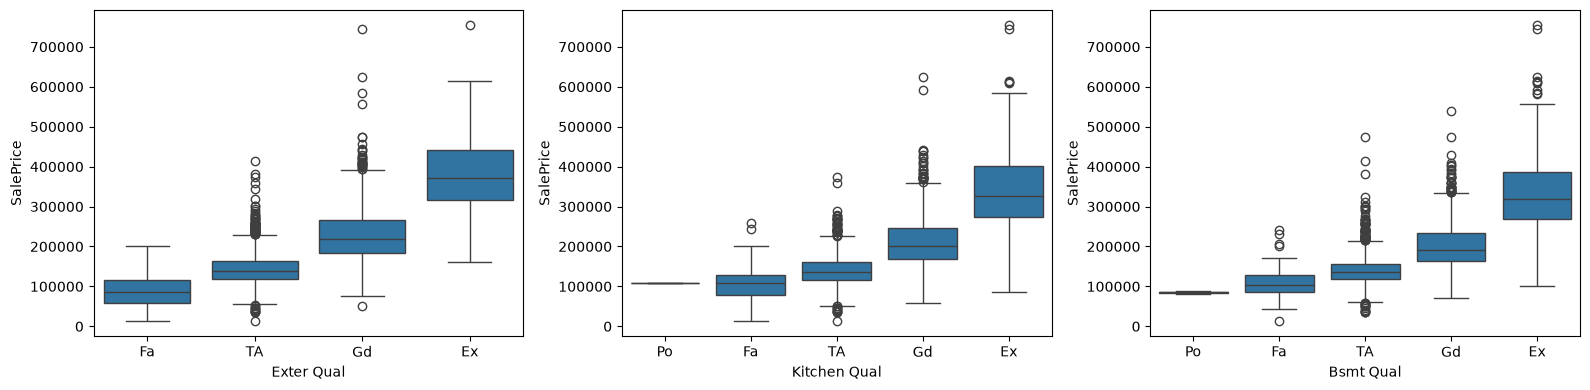

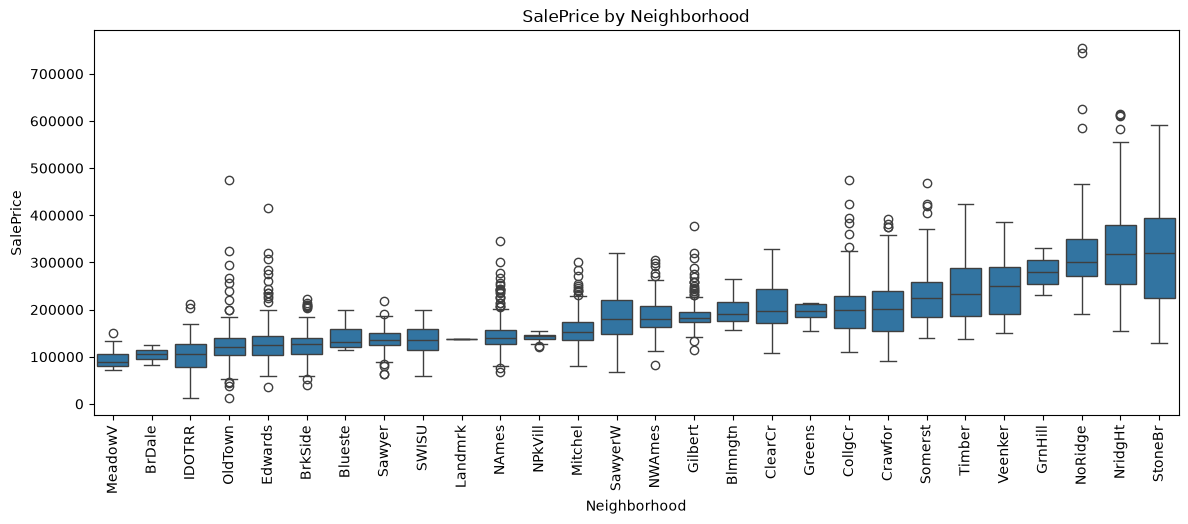

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Exter Qual", "Kitchen Qual", "Bsmt Qual"]):
    order = df.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(x=col, y="SalePrice", data=df, order=order, ax=ax)
plt.tight_layout()
plt.show()

# Neighborhood has many categories – give it its own large plot
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index
plt.figure(figsize=(14, 5))
sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=order)
plt.xticks(rotation=90)
plt.title("SalePrice by Neighborhood")
plt.show()

*✏️ Your answer: Which variables seem most related to the price? Are some of them strongly correlated with each other (multicollinearity)? (→ Q1, Q2)*

---
## Step 2 – Create training and test data

Split the dataset into a training set and a test set. **All** further development (preprocessing, feature selection) must be done on the training data. The test set is only used at the very end.

In [78]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= RANDOM_STATE,
)

print(X_train.shape)
print(X_test.shape)


(2344, 81)
(586, 81)


*✏️ Your answer: How did you split the data, and why must the test set be kept separate? (→ Q3)*

* In this task, X was defined as all columns except SalePrice, while y was defined as the SalePrice column. This was done since the SalePrice is the target. The dataset was then split into training and test sets using train_test_split, with 80% of the data used for training and 20% used for testing. Finally, the sizes of the training and test sets were printed to verify the split.

---
## Step 3 – Prepare the data

Decide how to prepare the data for the models. **Important:** preprocessing must be *learned* (fit) on the training data and then *applied* (transform) in the same way to the test data.

Possible steps:
- handle missing values (based on what they mean in the guide)
- encode categorical variables
- scale/transform numerical variables where appropriate
- remove variables when there is a clear reason to do so

### 3.1 Remove irrelevant columns

In [79]:
# ID columns – unique for every house, contain no information about the price
id_cols = ["Order", "PID"]

# Share of the most frequent value in each column – computed on the TRAINING data only
top_share = X_train.apply(lambda c: c.value_counts(normalize=True, dropna=False).iloc[0])
print(top_share.sort_values(ascending=False).head(12).round(3))

# 98 % of the training houses have the same value
near_constant = top_share[top_share >= 0.98].index.tolist()

# Misc values have to value in 96%
misc_cols = ["Misc Feature", "Misc Val"]

drop_cols = id_cols + near_constant + misc_cols
print("Dropping", len(drop_cols), "columns:", drop_cols)

# Ignore errors
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")
print("X_train:", X_train.shape, " X_test:", X_test.shape)

Utilities          0.999
Street             0.995
Pool Area          0.995
Pool QC            0.995
Condition 2        0.991
3Ssn Porch         0.988
Low Qual Fin SF    0.987
Heating            0.983
Roof Matl          0.983
Misc Val           0.961
Misc Feature       0.960
Kitchen AbvGr      0.956
dtype: float64
Dropping 13 columns: ['Order', 'PID', 'Street', 'Utilities', 'Condition 2', 'Roof Matl', 'Heating', 'Low Qual Fin SF', '3Ssn Porch', 'Pool Area', 'Pool QC', 'Misc Feature', 'Misc Val']
X_train: (2344, 68)  X_test: (586, 68)


### 3.2 Missing values that mean "does not exist"

In [80]:
def fill_absent_features(X):
    """Fill missing values that mean "the house does not have this feature" (see the dataset guide).
    Rule-based (not learned from data), so it is safe to apply to both X_train and X_test."""
    X = X.copy()

    # 1) Missing always means "does not exist"
    for col in ["Alley", "Fence", "Fireplace Qu"]:
        X[col] = X[col].fillna("None")

    # 2) Garage: 'Garage Type' missing = no garage (all these houses have Garage Area = 0).
    #    Houses that DO have a garage but a missing value keep NaN -> "not recorded", imputed in 3.3.
    no_garage = X["Garage Type"].isna()
    for col in ["Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"]:
        X.loc[no_garage, col] = "None"

    # 3) Basement: no basement if 'Bsmt Qual' is missing and the total basement area is 0 (or missing)
    no_bsmt = X["Bsmt Qual"].isna() & X["Total Bsmt SF"].fillna(0).eq(0)
    for col in ["Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]:
        X.loc[no_bsmt, col] = "None"
    for col in ["BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF",
                "Bsmt Full Bath", "Bsmt Half Bath"]:
        X.loc[no_bsmt, col] = X.loc[no_bsmt, col].fillna(0)

    # 4) Masonry veneer: type missing and area = 0 -> no veneer.
    #    Type missing but area > 0 (or missing) -> "not recorded", imputed in 3.3.
    no_veneer = X["Mas Vnr Type"].isna() & X["Mas Vnr Area"].eq(0)
    X.loc[no_veneer, "Mas Vnr Type"] = "None"

    return X


X_train = fill_absent_features(X_train)
X_test = fill_absent_features(X_test)

# Remaining missing values in the training data = "not recorded" -> handled by the imputers in 3.3
remaining = X_train.isnull().sum()
remaining[remaining > 0].sort_values(ascending=False)

Lot Frontage      393
Garage Yr Blt     122
Mas Vnr Type       26
Mas Vnr Area       19
Bsmt Exposure       2
Garage Finish       2
Garage Cond         2
Garage Qual         2
BsmtFin Type 2      1
Garage Area         1
Garage Cars         1
dtype: int64

### 3.3 Preprocessing pipeline (imputation, encoding, scaling)

In [81]:
# 'MS SubClass' is a code for the type of dwelling (20, 60, 190, ...), not a quantity -> treat it as categorical
X_train["MS SubClass"] = X_train["MS SubClass"].astype(str)
X_test["MS SubClass"] = X_test["MS SubClass"].astype(str)


def make_preprocessor(num_features, cat_features):
    """Build a new (unfitted) preprocessor for the given feature lists.
    Used again in Step 4/5 when the final feature lists are chosen."""
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),         # "not recorded" numbers -> training median
        ("scaler", StandardScaler()),                          # mean 0, std 1 (mainly for Linear Regression)
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  # "not recorded" categories -> most common in training
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ])


# For now: use all remaining columns (the final selection is done in Step 4)
num_features = X_train.select_dtypes(include="number").columns.tolist()
cat_features = X_train.select_dtypes(exclude="number").columns.tolist()
print(len(num_features), "numerical and", len(cat_features), "categorical features")

preprocessor = make_preprocessor(num_features, cat_features)

# Fit ONLY on the training data, then apply the same learned transformation to the test data
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print("X_train_prep:", X_train_prep.shape, " X_test_prep:", X_test_prep.shape)

# Example of values learned from the training data
medians = pd.Series(preprocessor.named_transformers_["num"]["imputer"].statistics_, index=num_features)
print("Median 'Lot Frontage' learned from training data:", medians["Lot Frontage"])
print("Missing values left after preprocessing:", np.isnan(X_train_prep).sum(), "(train),", np.isnan(X_test_prep).sum(), "(test)")

31 numerical and 37 categorical features
X_train_prep: (2344, 289)  X_test_prep: (586, 289)
Median 'Lot Frontage' learned from training data: 68.0
Missing values left after preprocessing: 0 (train), 0 (test)


*✏️ Your answer: Explain your choices for missing values, categorical variables and scaling. Why is this learned only from the training data? (→ Q4)*

---
## Step 4 – Select and engineer features

Decide which features to use. Use evidence from the **training data** (correlations, plots, understanding of the variables). You do not have to use every column.

*Tip: Steps 3 and 4 are connected – it may be easiest to do the feature engineering (4.1) before building the pipeline in 3.3, since the pipeline needs the final `num_features` and `cat_features` lists.*

### 4.1 Feature engineering

In [82]:
def add_features(X):
    """Create new features from existing columns. Rule-based, so it is applied to both X_train and X_test."""
    X = X.copy()

    # Total living space incl. basement – buyers pay for the total size of the house
    X["Total SF"] = X["Total Bsmt SF"] + X["1st Flr SF"] + X["2nd Flr SF"]

    # Age of the house and years since remodelling at the time of sale (clip: one house was sold before it was finished)
    X["House Age"] = (X["Yr Sold"] - X["Year Built"]).clip(lower=0)
    X["Remod Age"] = (X["Yr Sold"] - X["Year Remod/Add"]).clip(lower=0)

    # Total number of bathrooms (a half bath counts as 0.5)
    X["Total Bath"] = (X["Full Bath"] + 0.5 * X["Half Bath"]
                       + X["Bsmt Full Bath"] + 0.5 * X["Bsmt Half Bath"])

    # Total outdoor area (deck + porches)
    X["Total Porch SF"] = (X["Wood Deck SF"] + X["Open Porch SF"]
                           + X["Enclosed Porch"] + X["Screen Porch"])

    # Has the house been remodelled? (Year Remod/Add equals Year Built if not)
    X["Remodeled"] = (X["Year Remod/Add"] != X["Year Built"]).astype(int)

    return X


X_train = add_features(X_train)
X_test = add_features(X_test)

new_features = ["Total SF", "House Age", "Remod Age", "Total Bath", "Total Porch SF", "Remodeled"]

In [83]:
# Correlation with SalePrice – computed on the TRAINING data only
compare = ["Total SF", "Gr Liv Area", "Total Bsmt SF", "1st Flr SF",
           "House Age", "Year Built", "Remod Age", "Year Remod/Add",
           "Total Bath", "Full Bath", "Total Porch SF", "Wood Deck SF", "Open Porch SF", "Remodeled"]
X_train[compare].corrwith(y_train).round(3).to_frame("corr with SalePrice")

,corr with SalePrice
Total SF,0.778
Gr Liv Area,0.698
Total Bsmt SF,0.613
1st Flr SF,0.607
House Age,-0.546
Year Built,0.545
Remod Age,-0.520
Year Remod/Add,0.518
Total Bath,0.639
Full Bath,0.542


### 4.2 Feature selection

In [84]:
# --- Numerical features: correlation with SalePrice (TRAINING data only) ---
num_all = X_train.select_dtypes(include="number").columns
num_corr = X_train[num_all].corrwith(y_train).sort_values(key=abs, ascending=False)

# 1) Keep features with at least a moderate linear relationship with price
CORR_THRESHOLD = 0.3
candidates = num_corr[num_corr.abs() >= CORR_THRESHOLD].index.tolist()

# 2) Remove redundancy: go through the candidates from strongest to weakest, and skip a feature
#    if it is almost a duplicate (|r| > 0.8) of a feature that is already selected
REDUNDANCY_THRESHOLD = 0.8
feature_corr = X_train[candidates].corr().abs()
num_features, removed = [], {}
for col in candidates:
    duplicate_of = [kept for kept in num_features if feature_corr.loc[col, kept] > REDUNDANCY_THRESHOLD]
    if duplicate_of:
        removed[col] = f"r = {feature_corr.loc[col, duplicate_of[0]]:.2f} with '{duplicate_of[0]}'"
    else:
        num_features.append(col)

print(f"{len(candidates)} of {len(num_all)} numerical features have |r| >= {CORR_THRESHOLD}")
print("\nRemoved as redundant:")
for col, reason in removed.items():
    print(f"  {col:15s} {reason}")
print(f"\nSelected numerical features ({len(num_features)}):")
num_corr[num_features].round(3).to_frame("corr with SalePrice")

21 of 37 numerical features have |r| >= 0.3

Removed as redundant:
  Gr Liv Area     r = 0.87 with 'Total SF'
  Garage Area     r = 0.88 with 'Garage Cars'
  Total Bsmt SF   r = 0.83 with 'Total SF'
  Year Built      r = 1.00 with 'House Age'
  Year Remod/Add  r = 1.00 with 'Remod Age'
  Garage Yr Blt   r = 0.82 with 'House Age'

Selected numerical features (15):


,corr with SalePrice
Overall Qual,0.795
Total SF,0.778
Garage Cars,0.644
Total Bath,0.639
1st Flr SF,0.607
House Age,-0.546
Full Bath,0.542
Remod Age,-0.520
Mas Vnr Area,0.491
TotRms AbvGrd,0.475


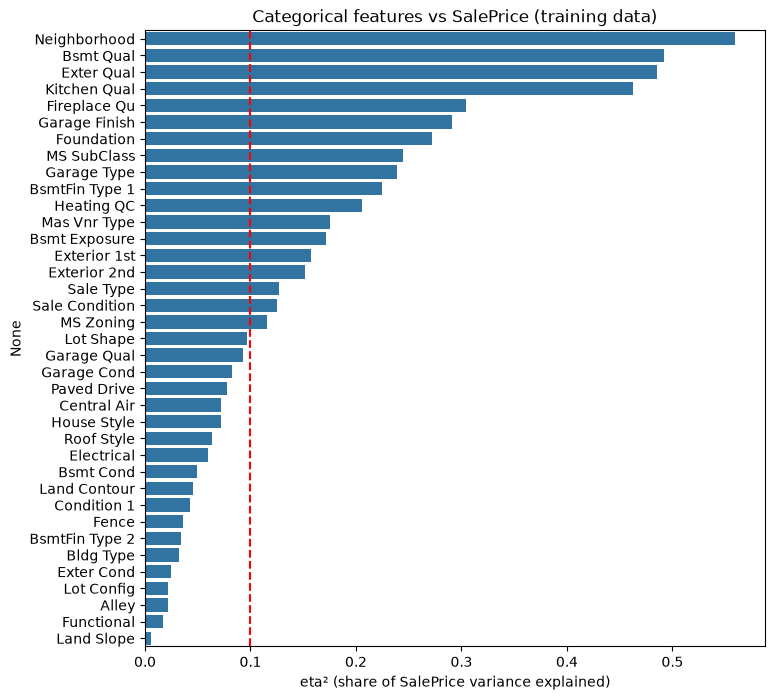

'Exterior 1st' == 'Exterior 2nd' for 85% of the houses

Selected categorical features (17):


,eta²
Neighborhood,0.560
Bsmt Qual,0.492
Exter Qual,0.486
Kitchen Qual,0.463
Fireplace Qu,0.304
Garage Finish,0.291
Foundation,0.272
MS SubClass,0.244
Garage Type,0.239
BsmtFin Type 1,0.225


In [85]:
# --- Categorical features: how much of the variation in SalePrice is explained by the category? ---
# Correlation ratio (eta²): 0 = the category says nothing about price, 1 = the category determines the price.
def eta_squared(x, y):
    group_means = y.groupby(x.fillna("Missing")).transform("mean")
    return ((group_means - y.mean()) ** 2).sum() / ((y - y.mean()) ** 2).sum()

cat_all = X_train.select_dtypes(exclude="number").columns
cat_eta = pd.Series({col: eta_squared(X_train[col], y_train) for col in cat_all}).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=cat_eta.values, y=cat_eta.index)
ETA_THRESHOLD = 0.1
plt.axvline(ETA_THRESHOLD, color="red", linestyle="--")
plt.xlabel("eta² (share of SalePrice variance explained)")
plt.title("Categorical features vs SalePrice (training data)")
plt.show()

cat_features = cat_eta[cat_eta >= ETA_THRESHOLD].index.tolist()

# 'Exterior 2nd' is the same as 'Exterior 1st' for most houses (only differs if the house has two materials)
print(f"'Exterior 1st' == 'Exterior 2nd' for {(X_train['Exterior 1st'] == X_train['Exterior 2nd']).mean():.0%} of the houses")
cat_features.remove("Exterior 2nd")

print(f"\nSelected categorical features ({len(cat_features)}):")
cat_eta[cat_features].round(3).to_frame("eta²")

In [86]:
# --- Final feature lists -> rebuild the preprocessor from 3.3 ---
print(f"Final features: {len(num_features)} numerical + {len(cat_features)} categorical")
print("Numerical:  ", num_features)
print("Categorical:", cat_features)

preprocessor = make_preprocessor(num_features, cat_features)
X_train_prep = preprocessor.fit_transform(X_train)   # fit on training data only
X_test_prep = preprocessor.transform(X_test)
print("\nX_train_prep:", X_train_prep.shape, " X_test_prep:", X_test_prep.shape)

Final features: 15 numerical + 17 categorical
Numerical:   ['Overall Qual', 'Total SF', 'Garage Cars', 'Total Bath', '1st Flr SF', 'House Age', 'Full Bath', 'Remod Age', 'Mas Vnr Area', 'TotRms AbvGrd', 'Fireplaces', 'BsmtFin SF 1', 'Total Porch SF', 'Wood Deck SF', 'Lot Frontage']
Categorical: ['Neighborhood', 'Bsmt Qual', 'Exter Qual', 'Kitchen Qual', 'Fireplace Qu', 'Garage Finish', 'Foundation', 'MS SubClass', 'Garage Type', 'BsmtFin Type 1', 'Heating QC', 'Mas Vnr Type', 'Bsmt Exposure', 'Exterior 1st', 'Sale Type', 'Sale Condition', 'MS Zoning']

X_train_prep: (2344, 157)  X_test_prep: (586, 157)


*✏️ Your answer: Which features did you finally use? What did you remove/create, and why? (→ Q2, Q5)*

---
## Step 5 – Train the models

Train the three models **using the same prepared features**, so that they can be compared fairly. Use the default hyperparameters (no tuning required).

- `LinearRegression`
- `DecisionTreeRegressor`
- `RandomForestRegressor`

In [87]:
models = {
     "Linear Regression": LinearRegression(),
     "Decision Tree Regression": DecisionTreeRegressor(random_state=RANDOM_STATE),
     "Random Forest Regression": RandomForestRegressor(random_state=RANDOM_STATE),
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

---
## Step 6 – Evaluate and interpret the results

Evaluate all three models on the **test data** using:
- **RMSE** – the size of the prediction errors in the same units as `SalePrice` (lower is better)
- **R²** – compares the predictions with a baseline that always predicts the mean (higher is generally better; 1 = perfect, 0 = no better than the mean, can be negative). *Do not describe R² as percentage accuracy.*

| Model | Test RMSE | Test R² |
|---|---|---|
| Linear Regression | | |
| Decision Tree Regression | | |
| Random Forest Regression | | |

In [88]:
# HINT: For each trained model:
#   y_pred = model.predict(X_test)
#   rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#   r2   = r2_score(y_test, y_pred)
# Collect the results in a pd.DataFrame with the columns "Model", "Test RMSE", "Test R²".
# If you log-transformed y: remember to transform the predictions back (np.expm1) before computing RMSE!

### 6.1 Visualizing the predictions

In [89]:
# HINT: Scatter plot of y_test (x-axis) vs y_pred (y-axis) for each model,
# with a diagonal line y = x for perfect predictions. Consider plt.subplots(1, 3).
# Look for where the models make the largest errors (expensive houses? cheap houses?).

*✏️ Your answer: Which model performed best on the test data? Why do you think so? (→ Q6)*

---
## Summary and possible improvements

*✏️ Your answer: What could you change in the preprocessing or features to improve the results without changing to a different model? (→ Q7)*